# Nettoyage du Dataset Anime (PySpark & Matplotlib)

Ce notebook documente l'analyse exploratoire, le traitement des valeurs manquantes (trous de données) et des valeurs aberrantes (outliers) pour le dataset `anime_dataset.csv` en utilisant **PySpark** et **Matplotlib**.

## Objectifs :
1. **Identifier les données manquantes** et définir une stratégie d'imputation cohérente.
2. **Identifier les valeurs aberrantes** (distinction entre anomalies réelles de saisie et valeurs extrêmes statistiquement atypiques mais valides).
3. **Nettoyer les données** en utilisant PySpark.
4. **Visualiser les résultats** avant et après le nettoyage.
5. **Sauvegarder le jeu de données nettoyé**.


In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Initialiser la session Spark
spark = SparkSession.builder \
                    .appName("Anime Data Cleaning") \
                    .getOrCreate()

# Réduire les logs Spark pour une meilleure lisibilité dans Jupyter
spark.sparkContext.setLogLevel("ERROR")

# Activer l'évaluation dynamique pour un affichage propre des DataFrames
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)

# Charger les données avec les options pour gérer les sauts de ligne dans les champs de texte
df = spark.read \
          .option("multiLine", True) \
          .option("escape", '"') \
          .csv("data/anime_dataset.csv", header=True, inferSchema=True)

print(f"Dimensions du dataset original : {df.count()} lignes, {len(df.columns)} colonnes.")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/05/29 14:02:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


26/05/29 14:02:15 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/05/29 14:02:15 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


Dimensions du dataset original : 4985 lignes, 32 colonnes.


## 1. Analyse des valeurs manquantes (Trous de données)

Identifions d'abord le nombre de valeurs manquantes par colonne pour concevoir notre plan de nettoyage.


In [2]:
# Calculer le nombre de valeurs nulles par colonne en PySpark (une seule passe)
total_rows = df.count()
null_exprs = [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns]
null_counts_row = df.select(null_exprs).collect()[0].asDict()

null_counts = []
for col_name, null_c in null_counts_row.items():
    if null_c > 0:
        pct = (null_c / total_rows) * 100
        null_counts.append((col_name, null_c, pct))

# Créer un DataFrame de résumé uniquement pour l'affichage de la donnée
missing_df = pd.DataFrame(null_counts, columns=["Colonne", "Valeurs Manquantes", "Pourcentage (%)"])
missing_df = missing_df.sort_values(by="Valeurs Manquantes", ascending=False).reset_index(drop=True)
missing_df

,Colonne,Valeurs Manquantes,Pourcentage (%)
0,season_year,1946,39.037111
1,season,1946,39.037111
2,synonyms,1688,33.861585
3,end_year,1438,28.846540
4,end_day,1438,28.846540
5,end_month,1438,28.846540
6,title_english,750,15.045135
7,tags,689,13.821464
8,rank,189,3.791374
9,episodes,86,1.725176


## 2. Analyse des valeurs aberrantes (Outliers)

Les valeurs aberrantes peuvent être de deux types :
1. **Erreurs de saisie / Incohérences logiques** (ex: date de fin antérieure à la date de début).
2. **Valeurs statistiques extrêmes mais valides** (ex: séries à très long cours comme *Doraemon* avec plus de 1700 épisodes).

### 2.1 Incohérences Temporelles
Vérifions si certaines dates de début sont postérieures aux dates de fin.


In [3]:
# Incohérence start > end
incoherent_dates = df.filter(
    (F.col("start_year") > F.col("end_year")) |
    ((F.col("start_year") == F.col("end_year")) & (F.col("start_month") > F.col("end_month"))) |
    ((F.col("start_year") == F.col("end_year")) & (F.col("start_month") == F.col("end_month")) & (F.col("start_day") > F.col("end_day")))
)

print(f"Nombre d'incohérences de date directes : {incoherent_dates.count()}")
if incoherent_dates.count() > 0:
    incoherent_dates.select("mal_id", "title_romaji", "start_year", "start_month", "end_year", "end_month").show()


Nombre d'incohérences de date directes : 1


+------+--------------------+----------+-----------+--------+---------+
|mal_id|        title_romaji|start_year|start_month|end_year|end_month|
+------+--------------------+----------+-----------+--------+---------+
| 10330|Bakugan Battle Br...|    2018.0|        9.0|  2018.0|      1.0|
+------+--------------------+----------+-----------+--------+---------+



### 2.2 Outliers Statistiques (IQR Method)
Utilisons l'écart interquartile (IQR) pour identifier les outliers sur les colonnes numériques : `episodes`, `duration_min`, `score`, et `members`.


In [4]:
num_cols = ["episodes", "duration_min", "score", "members"]

for col in num_cols:
    # Calculer Q1, Q3 et IQR
    quantiles = df.approxQuantile(col, [0.25, 0.75], 0.01)
    if len(quantiles) == 2:
        q1, q3 = quantiles[0], quantiles[1]
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outliers_count = df.filter((F.col(col) < lower_bound) | (F.col(col) > upper_bound)).count()
        pct = (outliers_count / total_rows) * 100
        
        print(f"Colonne '{col}' : Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
        print(f"  Nombre d'outliers : {outliers_count} ({pct:.2f}%)\n")


Colonne 'episodes' : Q1=2.00, Q3=13.00, IQR=11.00
  Nombre d'outliers : 256 (5.14%)



Colonne 'duration_min' : Q1=23.00, Q3=25.00, IQR=2.00
  Nombre d'outliers : 1438 (28.85%)



Colonne 'score' : Q1=6.79, Q3=7.70, IQR=0.91
  Nombre d'outliers : 57 (1.14%)



Colonne 'members' : Q1=46322.00, Q3=220083.00, IQR=173761.00
  Nombre d'outliers : 541 (10.85%)



### 2.3 Examen des valeurs maximales et minimales
Regardons de plus près les extrêmes de `episodes` et `duration_min` pour voir si ce sont des erreurs ou des cas valides.


In [5]:
print("Top 5 animés avec le plus d'épisodes :")
df.orderBy(F.col("episodes").desc()).select("title_romaji", "episodes", "format").show(5)

print("Top 5 animés les plus longs (durée en minutes) :")
df.orderBy(F.col("duration_min").desc()).select("title_romaji", "duration_min", "format").show(5)


Top 5 animés avec le plus d'épisodes :


+------------------+--------+------+
|      title_romaji|episodes|format|
+------------------+--------+------+
|   Doraemon (1979)|  1787.0|    TV|
|Naruto: Shippuuden|   500.0|    TV|
|            Bleach|   366.0|    TV|
|     Keroro Gunsou|   358.0|    TV|
|  Tottoko Hamtarou|   296.0|    TV|
+------------------+--------+------+
only showing top 5 rows
Top 5 animés les plus longs (durée en minutes) :
+--------------------+------------+------+
|        title_romaji|duration_min|format|
+--------------------+------------+------+
|Kono Sekai no Kat...|       168.0| Movie|
|Suzumiya Haruhi n...|       161.0| Movie|
|Koukaku Kidoutai:...|       161.0|   OVA|
|Koukaku Kidoutai:...|       160.0|   OVA|
|Kimetsu no Yaiba ...|       155.0| Movie|
+--------------------+------------+------+
only showing top 5 rows


## 3. Stratégie de Nettoyage (Data Cleaning)

Voici notre stratégie pour nettoyer le dataset :
1. **Corriger l'incohérence temporelle** : Pour l'animé *Bakugan Battle Brawlers: Mechtanium Surge* (mal_id 10330), les mois de début (9.0) et de fin (1.0) en 2018 sont inversés. Nous allons les échanger pour avoir un début en janvier et une fin en septembre (cohérent avec 46 épisodes).
2. **Propager les dates de fin pour les diffusions uniques** : Si `status == 'Finished Airing'` et que `end_year` est nul alors que l'animé est un format à diffusion unique (Movie, OVA, Special, ONA, TV Special, Music, PV, CM) ou qu'il ne possède qu'un seul épisode, nous copions les dates de début vers les dates de fin.
3. **Imputer la durée (`duration_min`)** : Pour les animés terminés ayant une durée manquante (ex: certains ONA ou Specials), nous imputons la durée par la valeur **médiane** de leur format respectif.
4. **Imputer la saison et l'année de saison (`season`, `season_year`)** :
   - Hiver : Décembre (12), Janvier (1), Février (2)
   - Printemps : Mars (3), Avril (4), Mai (5)
   - Été : Juin (6), Juillet (7), Août (8)
   - Automne : Septembre (9), Octobre (10), Novembre (11)
   - Si le mois est décembre (12), l'année de saison (`season_year`) est `start_year + 1`, sinon c'est `start_year`.
5. **Remplacer les textes nuls** :
   - `title_english` & `title_native` -> remplacer par `title_romaji` si manquants.
   - `description` -> "No description available."
   - `genres`, `tags`, `studios`, `format`, `rating` -> "Unknown".


In [6]:
# 1. Correction de l'anomalie Bakugan (mal_id 10330)
df_clean = df.withColumn("start_month", F.when(F.col("mal_id") == 10330, 1.0).otherwise(F.col("start_month")))
df_clean = df_clean.withColumn("end_month", F.when(F.col("mal_id") == 10330, 9.0).otherwise(F.col("end_month")))

# 2. Propagation des dates pour les diffusions uniques
single_formats = ['Movie', 'OVA', 'Special', 'ONA', 'TV Special', 'Music', 'PV', 'CM']
df_clean = df_clean.withColumn("end_year", 
    F.when((F.col("status") == "Finished Airing") & F.col("end_year").isNull() & 
           (F.col("format").isin(single_formats) | (F.col("episodes") == 1)), F.col("start_year"))
     .otherwise(F.col("end_year"))
)
df_clean = df_clean.withColumn("end_month", 
    F.when((F.col("status") == "Finished Airing") & F.col("end_month").isNull() & 
           (F.col("format").isin(single_formats) | (F.col("episodes") == 1)), F.col("start_month"))
     .otherwise(F.col("end_month"))
)
df_clean = df_clean.withColumn("end_day", 
    F.when((F.col("status") == "Finished Airing") & F.col("end_day").isNull() & 
           (F.col("format").isin(single_formats) | (F.col("episodes") == 1)), F.col("start_day"))
     .otherwise(F.col("end_day"))
)

# 3. Imputation des durées manquantes pour les animés terminés par la médiane de leur format
# Calcul des médianes par format
format_medians = df_clean.groupBy("format").agg(F.percentile_approx("duration_min", 0.5).alias("median_duration")).collect()
medians_dict = {row['format']: row['median_duration'] for row in format_medians if row['format'] is not None}

# Construire la logique de remplacement en PySpark
duration_expr = F.col("duration_min")
for fmt, med_val in medians_dict.items():
    duration_expr = F.when(
        F.col("duration_min").isNull() & (F.col("status") == "Finished Airing") & (F.col("format") == fmt),
        med_val
    ).otherwise(duration_expr)

df_clean = df_clean.withColumn("duration_min", duration_expr)

# 4. Imputation de season et season_year
df_clean = df_clean.withColumn("season",
    F.when(F.col("season").isNull() & F.col("start_month").isNotNull(),
           F.when(F.col("start_month").isin(12, 1, 2), "winter")
            .when(F.col("start_month").isin(3, 4, 5), "spring")
            .when(F.col("start_month").isin(6, 7, 8), "summer")
            .when(F.col("start_month").isin(9, 10, 11), "fall")
    ).otherwise(F.col("season"))
)

df_clean = df_clean.withColumn("season_year",
    F.when(F.col("season_year").isNull() & F.col("start_month").isNotNull(),
           F.when(F.col("start_month") == 12, F.col("start_year") + 1)
            .otherwise(F.col("start_year"))
    ).otherwise(F.col("season_year"))
)

# 5. Remplacement des valeurs textuelles nulles
df_clean = df_clean.withColumn("title_english", F.coalesce(F.col("title_english"), F.col("title_romaji")))
df_clean = df_clean.withColumn("title_native", F.coalesce(F.col("title_native"), F.col("title_romaji")))
df_clean = df_clean.withColumn("description", F.coalesce(F.col("description"), F.lit("No description available.")))
df_clean = df_clean.withColumn("genres", F.coalesce(F.col("genres"), F.lit("Unknown")))
df_clean = df_clean.withColumn("tags", F.coalesce(F.col("tags"), F.lit("Unknown")))
df_clean = df_clean.withColumn("studios", F.coalesce(F.col("studios"), F.lit("Unknown")))
df_clean = df_clean.withColumn("format", F.coalesce(F.col("format"), F.lit("Unknown")))
df_clean = df_clean.withColumn("rating", F.coalesce(F.col("rating"), F.lit("Unknown")))

print("Nettoyage terminé avec succès.")


Nettoyage terminé avec succès.


## 4. Vérification post-nettoyage et Sauvegarde

Vérifions le nombre de valeurs manquantes restantes après nos opérations de nettoyage.


In [7]:
# Calculer le nombre de valeurs nulles par colonne en PySpark (une seule passe)
total_rows_clean = df_clean.count()
null_exprs_clean = [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df_clean.columns]
null_counts_clean_row = df_clean.select(null_exprs_clean).collect()[0].asDict()

null_counts_clean = []
for col_name, null_c in null_counts_clean_row.items():
    if null_c > 0:
        pct = (null_c / total_rows_clean) * 100
        null_counts_clean.append((col_name, null_c, pct))

missing_df_clean = pd.DataFrame(null_counts_clean, columns=["Colonne", "Valeurs Manquantes Post-Clean", "Pourcentage (%)"])
print("Valeurs manquantes restantes :")
print(missing_df_clean)

# Sauvegarder le dataset nettoyé sous forme de fichier CSV unique avec PySpark (sans toPandas)
import glob
import shutil

os.makedirs("data", exist_ok=True)
temp_dir = "data/temp_anime_dataset_cleaned"

# Écrire le fichier en un seul morceau via PySpark
df_clean.coalesce(1).write.mode("overwrite").option("header", "true").csv(temp_dir)

# Récupérer et renommer le fichier CSV généré
csv_files = glob.glob(os.path.join(temp_dir, "*.csv"))
if csv_files:
    dest_path = "data/anime_dataset_cleaned.csv"
    if os.path.exists(dest_path):
        os.remove(dest_path)
    shutil.move(csv_files[0], dest_path)

# Nettoyer le répertoire temporaire de Spark
if os.path.exists(temp_dir):
    shutil.rmtree(temp_dir)

print("\nDataset nettoyé sauvegardé dans 'data/anime_dataset_cleaned.csv'.")

Valeurs manquantes restantes :
         Colonne  Valeurs Manquantes Post-Clean  Pourcentage (%)
0       synonyms                           1688        33.861585
1       episodes                             86         1.725176
2   duration_min                             74         1.484453
3     start_year                             34         0.682046
4    start_month                             34         0.682046
5      start_day                             34         0.682046
6       end_year                            127         2.547643
7      end_month                            127         2.547643
8        end_day                            127         2.547643
9         season                             34         0.682046
10   season_year                             34         0.682046
11         score                             74         1.484453
12     scored_by                             74         1.484453
13          rank                            189         3.7


Dataset nettoyé sauvegardé dans 'data/anime_dataset_cleaned.csv'.


## 5. Visualisations Graphiques avec Matplotlib

Nous allons représenter :
1. La comparaison des valeurs manquantes avant et après nettoyage.
2. La distribution des notes (scores) des animés.
3. Les boxplots pour identifier visuellement les valeurs extrêmes (épisodes, durée).
4. Le diagramme de dispersion des scores en fonction du nombre de membres (popularité).


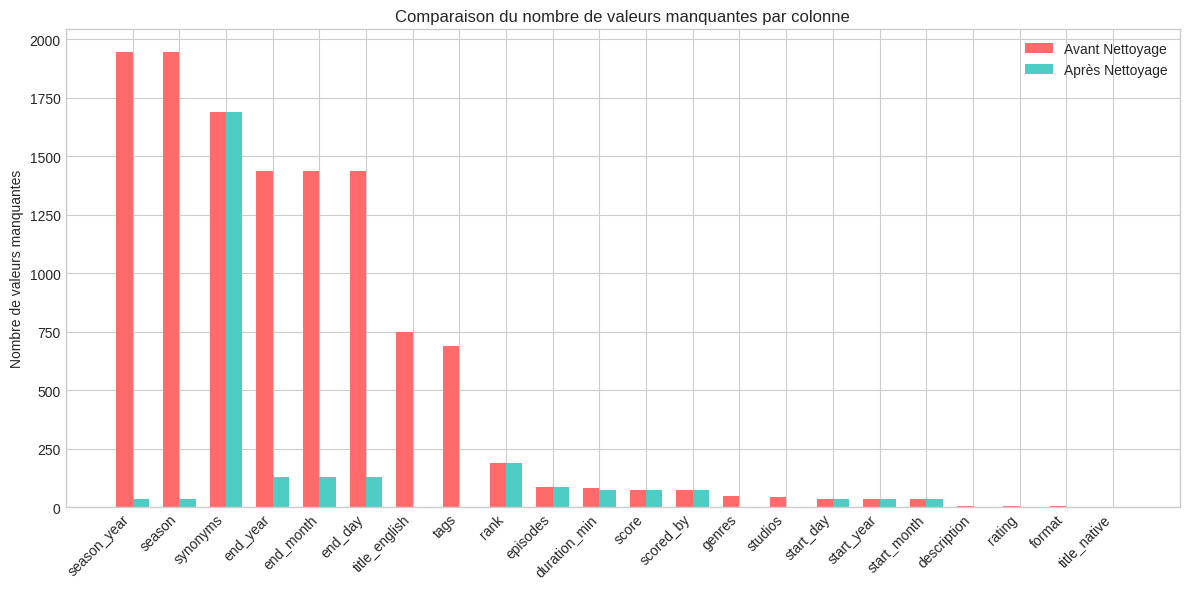

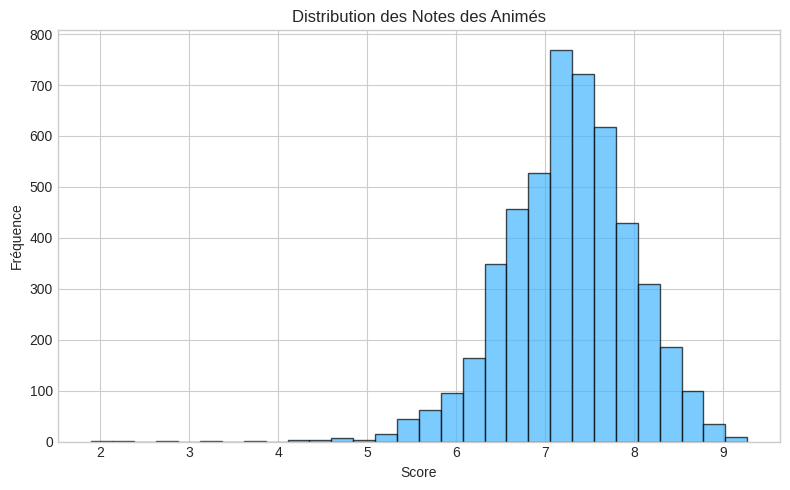

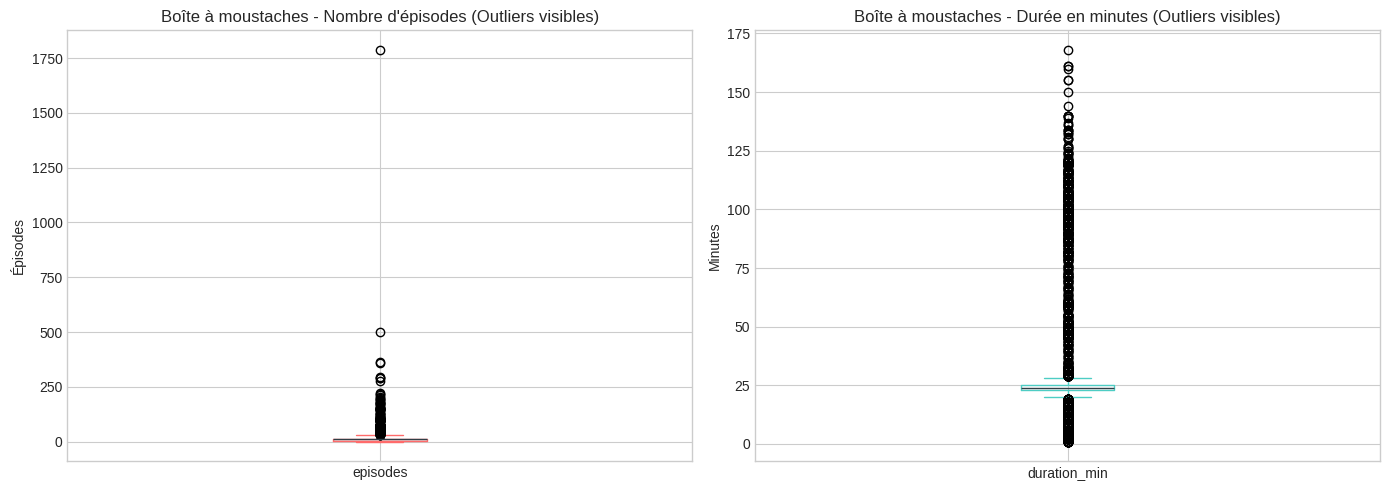

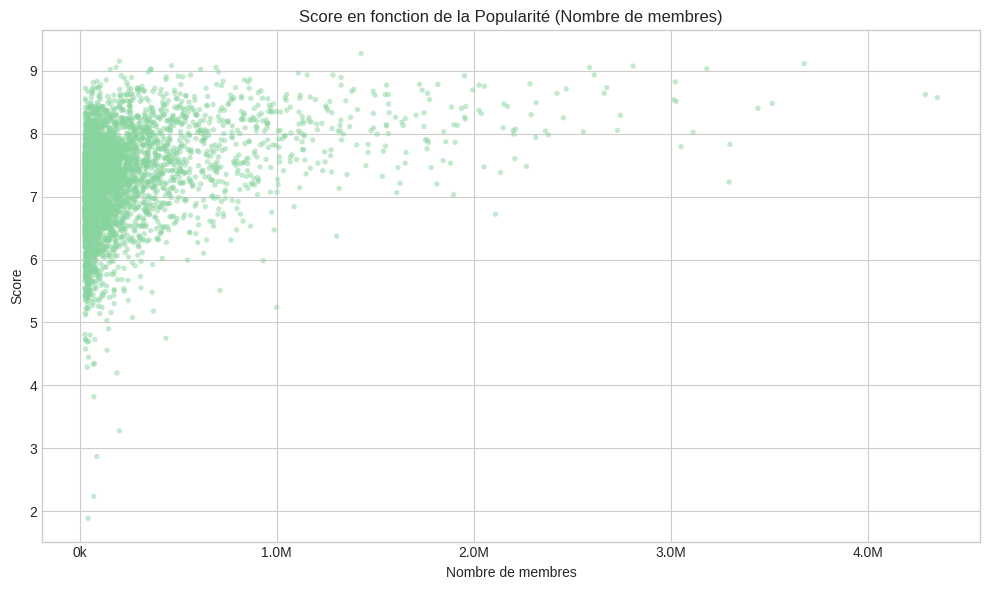

In [8]:
# Configuration du style des graphiques
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
os.makedirs("plots", exist_ok=True)

# Charger uniquement les colonnes requises pour la visualisation de la distribution (sans traitement)
df_clean_pd = df_clean.select("score", "episodes", "duration_min", "members").toPandas()

# 1. Comparaison des Valeurs Manquantes
fig, ax = plt.subplots(figsize=(12, 6))
# fusionner les deux dataframes de valeurs manquantes
comparison = pd.merge(missing_df, missing_df_clean, on="Colonne", how="outer").fillna(0)
comparison = comparison.sort_values(by="Valeurs Manquantes", ascending=False)

x = np.arange(len(comparison))
width = 0.35

ax.bar(x - width/2, comparison["Valeurs Manquantes"], width, label='Avant Nettoyage', color='#ff6b6b')
ax.bar(x + width/2, comparison["Valeurs Manquantes Post-Clean"], width, label='Après Nettoyage', color='#4ecdc4')

ax.set_ylabel('Nombre de valeurs manquantes')
ax.set_title('Comparaison du nombre de valeurs manquantes par colonne')
ax.set_xticks(x)
ax.set_xticklabels(comparison["Colonne"], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig("plots/missing_values_comparison.png", dpi=150)
plt.show()

# 2. Distribution des Scores
fig, ax = plt.subplots(figsize=(8, 5))
df_clean_pd['score'].plot(kind='hist', bins=30, color='#45b6fe', edgecolor='black', alpha=0.7, ax=ax)
ax.set_title('Distribution des Notes des Animés')
ax.set_xlabel('Score')
ax.set_ylabel('Fréquence')
plt.tight_layout()
plt.savefig("plots/score_distribution.png", dpi=150)
plt.show()

# 3. Boxplots des épisodes et durées (détection visuelle des outliers)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot Episodes
df_clean_pd.boxplot(column='episodes', ax=axes[0], color=dict(boxes='#ff6b6b', whiskers='#ff6b6b', medians='#2f3e46', caps='#ff6b6b'))
axes[0].set_title("Boîte à moustaches - Nombre d'épisodes (Outliers visibles)")
axes[0].set_ylabel("Épisodes")

# Boxplot Duration
df_clean_pd.boxplot(column='duration_min', ax=axes[1], color=dict(boxes='#4ecdc4', whiskers='#4ecdc4', medians='#2f3e46', caps='#4ecdc4'))
axes[1].set_title("Boîte à moustaches - Durée en minutes (Outliers visibles)")
axes[1].set_ylabel("Minutes")

plt.tight_layout()
plt.savefig("plots/outliers_boxplots.png", dpi=150)
plt.show()

# 4. Dispersion Score vs Members (Popularité)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_clean_pd['members'], df_clean_pd['score'], alpha=0.5, color='#88d49e', edgecolor='none', s=15)
ax.set_title('Score en fonction de la Popularité (Nombre de membres)')
ax.set_xlabel('Nombre de membres')
ax.set_ylabel('Score')
# Formater l'axe x pour une lecture plus facile (ex: 1M au lieu de 1000000)
import matplotlib.ticker as ticker
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M' if x >= 1e6 else f'{x*1e-3:.0f}k'))
plt.tight_layout()
plt.savefig("plots/score_vs_popularity.png", dpi=150)
plt.show()

## 6. Analyses statistiques complémentaires : Genres et Popularité

Pour répondre aux questions d'analyse plus poussées, nous étudions ici la structure des genres et de leur popularité :
1. **Genres les plus populaires globalement** : Classement des 10 genres ayant réuni le plus grand nombre de membres.
2. **Évolution de la popularité (membres) des 5 genres majeurs** : Suivi de 2000 à 2025 pour observer l'attractivité des genres au fil du temps.
3. **Évolution du volume de sorties des 5 genres majeurs** : Suivi de 2000 à 2025 du nombre de productions par genre.
4. **Top 3 des genres par décennie** : Analyse historique des tendances de genres des années 1980 à nos jours.

Nous utilisons **PySpark** pour la manipulation/l'explosion des données et **Matplotlib** pour les tracés.


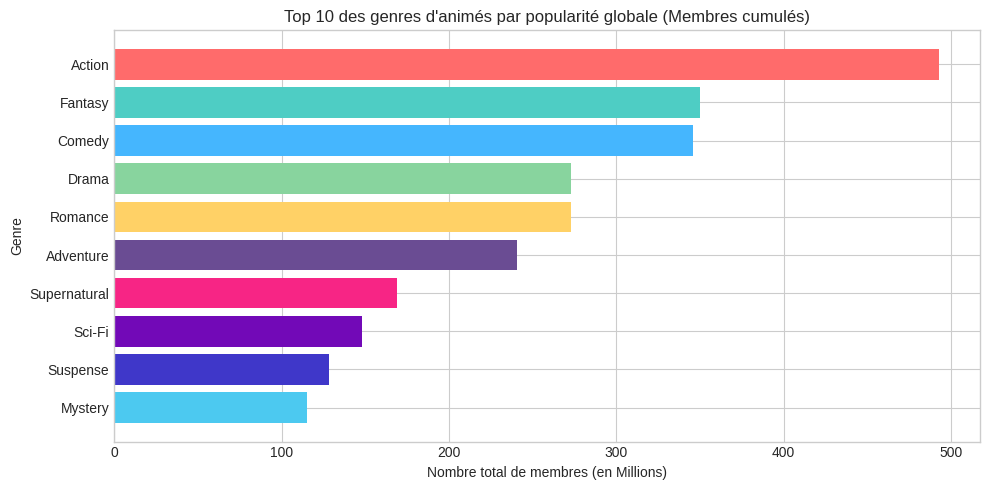

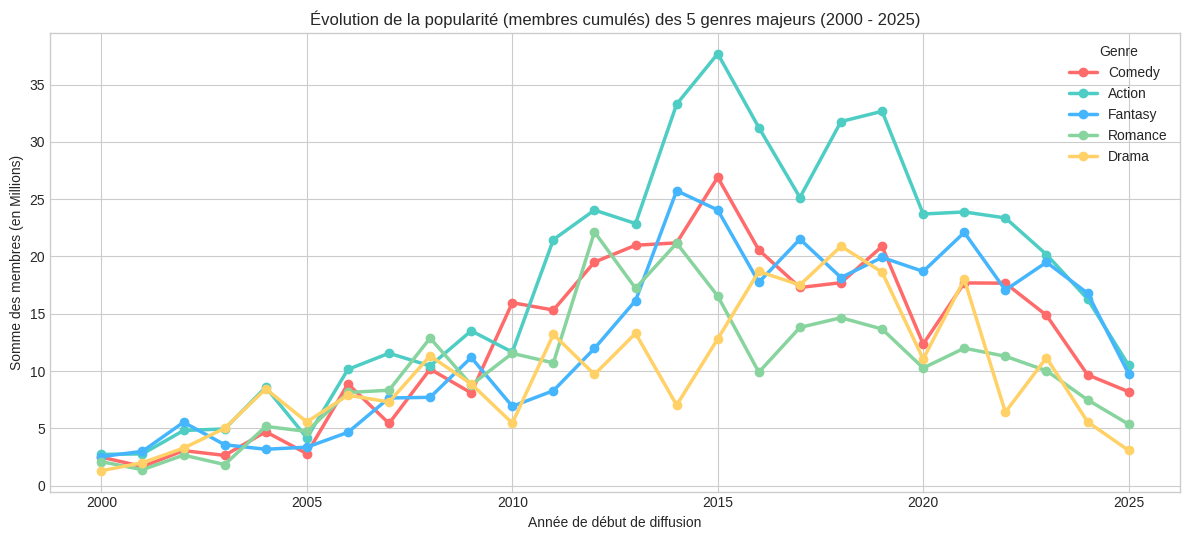

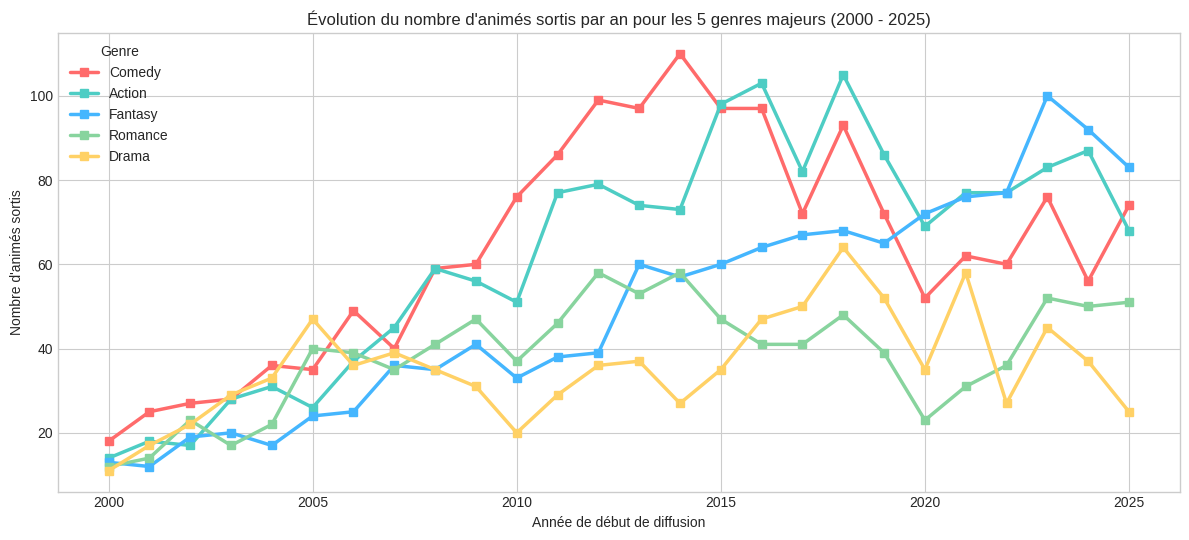

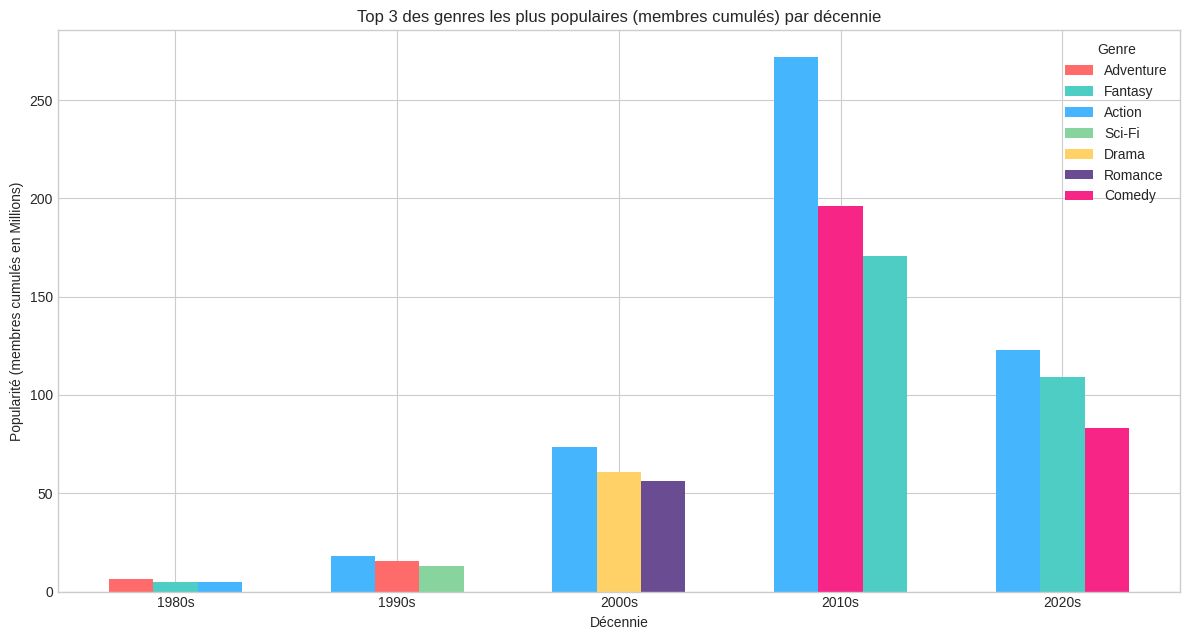

In [9]:
# 1. Explosion de la colonne 'genres' pour avoir une ligne par genre par animé
df_genres = df_clean.withColumn("genre", F.explode(F.split(F.col("genres"), "\\|")))

# Filtrer les genres invalides ou inconnus
df_genres = df_genres.filter((F.col("genre") != "Unknown") & (F.col("genre").isNotNull()) & (F.col("genre") != ""))

# Palette de couleurs personnalisées pour des graphiques esthétiques
colors = ['#ff6b6b', '#4ecdc4', '#45b6fe', '#88d49e', '#ffd166', '#6a4c93', '#f72585', '#7209b7', '#3f37c9', '#4cc9f0']

# --- Graphique 1 : Top 10 des genres par popularité cumulée (Membres) ---
# Traitement effectué entièrement en PySpark
top_genres_members_spark = df_genres.groupBy("genre").agg(F.sum("members").alias("total_members")) \
                                     .orderBy(F.col("total_members").desc()).limit(10)
# Seul le résultat final agrégé est converti pour l'affichage (10 lignes)
top_genres_members = top_genres_members_spark.toPandas().set_index("genre")["total_members"]

plt.figure(figsize=(10, 5))
plt.barh(top_genres_members.index[::-1], top_genres_members.values[::-1] / 1e6, color=colors[:10][::-1])
plt.title("Top 10 des genres d'animés par popularité globale (Membres cumulés)")
plt.xlabel("Nombre total de membres (en Millions)")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig("plots/top_genres_global.png", dpi=150)
plt.show()


# --- Graphique 2 : Évolution de la popularité (membres) des 5 genres majeurs (2000 - 2025) ---
# Traitement effectué entièrement en PySpark
top_5_genres_spark = df_genres.groupBy("genre").count() \
                               .orderBy(F.col("count").desc()).limit(5)
top_5_genres = [row['genre'] for row in top_5_genres_spark.select("genre").collect()]

df_filtered_spark = df_genres.filter(
    (F.col("genre").isin(top_5_genres)) & 
    (F.col("start_year") >= 2000) & 
    (F.col("start_year") <= 2025)
)

evolution_members_spark = df_filtered_spark.groupBy("start_year", "genre").agg(F.sum("members").alias("members")) \
                                           .orderBy("start_year", "genre")
# Seul le résultat final agrégé est converti pour l'affichage
evolution_members = evolution_members_spark.toPandas()

plt.figure(figsize=(12, 5.5))
for i, genre in enumerate(top_5_genres):
    genre_data = evolution_members[evolution_members["genre"] == genre]
    plt.plot(genre_data["start_year"], genre_data["members"] / 1e6, marker='o', linewidth=2.5, label=genre, color=colors[i])
plt.title("Évolution de la popularité (membres cumulés) des 5 genres majeurs (2000 - 2025)")
plt.xlabel("Année de début de diffusion")
plt.ylabel("Somme des membres (en Millions)")
plt.legend(title="Genre")
plt.tight_layout()
plt.savefig("plots/genre_evolution_popularity.png", dpi=150)
plt.show()


# --- Graphique 3 : Évolution du nombre de sorties d'animés par an pour les 5 genres majeurs (2000 - 2025) ---
# Traitement effectué entièrement en PySpark
evolution_count_spark = df_filtered_spark.groupBy("start_year", "genre").count() \
                                         .withColumnRenamed("count", "title_romaji") \
                                         .orderBy("start_year", "genre")
# Seul le résultat final agrégé est converti pour l'affichage
evolution_count = evolution_count_spark.toPandas()

plt.figure(figsize=(12, 5.5))
for i, genre in enumerate(top_5_genres):
    genre_data = evolution_count[evolution_count["genre"] == genre]
    plt.plot(genre_data["start_year"], genre_data["title_romaji"], marker='s', linewidth=2.5, label=genre, color=colors[i])
plt.title("Évolution du nombre d'animés sortis par an pour les 5 genres majeurs (2000 - 2025)")
plt.xlabel("Année de début de diffusion")
plt.ylabel("Nombre d'animés sortis")
plt.legend(title="Genre")
plt.tight_layout()
plt.savefig("plots/genre_evolution_count.png", dpi=150)
plt.show()


# --- Graphique 4 : Les genres les plus populaires par décennie (Top 3) ---
# Traitement effectué entièrement en PySpark (y compris la décennie et le fenêtrage)
df_genres_decade = df_genres.withColumn("decade", 
    F.when(F.col("start_year").isNull(), "Unknown")
     .otherwise(F.concat((F.floor(F.col("start_year") / 10) * 10).cast("int"), F.lit("s")))
)

decades_to_plot = ["1980s", "1990s", "2000s", "2010s", "2020s"]
df_decades_spark = df_genres_decade.filter(F.col("decade").isin(decades_to_plot))

# Groupby et somme des membres
decade_genres_spark = df_decades_spark.groupBy("decade", "genre").agg(F.sum("members").alias("members"))

# Top 3 par décennie en utilisant une fonction de fenêtrage Spark
from pyspark.sql.window import Window
windowSpec = Window.partitionBy("decade").orderBy(F.col("members").desc())
top_decade_genres_spark = decade_genres_spark.withColumn("rank", F.row_number().over(windowSpec)) \
                                             .filter(F.col("rank") <= 3) \
                                             .orderBy("decade", F.col("members").desc())

# Seul le résultat final agrégé est converti pour l'affichage (15 lignes au maximum)
top_decade_genres = top_decade_genres_spark.toPandas()

fig, ax = plt.subplots(figsize=(12, 6.5))
decades = sorted(top_decade_genres["decade"].unique())
genres = top_decade_genres["genre"].unique()
genre_colors = {genre: colors[k % len(colors)] for k, genre in enumerate(genres)}
x = np.arange(len(decades))
width = 0.2

for i, decade in enumerate(decades):
    decade_data = top_decade_genres[top_decade_genres["decade"] == decade]
    for j, (_, row) in enumerate(decade_data.iterrows()):
        genre = row["genre"]
        val = row["members"] / 1e6
        bar_pos = i + (j - 1) * width
        ax.bar(bar_pos, val, width, color=genre_colors[genre], label=genre if f"{genre}_label" not in ax.get_legend_handles_labels()[1] else "")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Genre")
ax.set_xticks(x)
ax.set_xticklabels(decades)
ax.set_title("Top 3 des genres les plus populaires (membres cumulés) par décennie")
ax.set_xlabel("Décennie")
ax.set_ylabel("Popularité (membres cumulés en Millions)")
plt.tight_layout()
plt.savefig("plots/top_genres_by_decade.png", dpi=150)
plt.show()

## Conclusion

Le dataset a été entièrement nettoyé à l'aide de PySpark :
- **Trous de données** : Réduits de manière significative. Les valeurs manquantes restantes sont principalement sur `end_year`/`end_month`/`end_day` pour les séries en cours de diffusion (`Currently Airing`) ou non commencées (`Not yet aired`), ce qui est cohérent et attendu. Les synonymes restent optionnels.
- **Valeurs aberrantes** :
  - L'anomalie logique de date pour *Bakugan* a été résolue par inversion des mois de début et de fin.
  - Les outliers statistiques sur le nombre d'épisodes (*Doraemon*) et la durée ont été conservés car ils représentent de réelles données atypiques mais valides (séries de longue date et films longs).
